# Spring 2026 Data Science Project

**Name(s):** Jazmine Yambo, Benjamin Nathan, Thomas Chuss,  Neil Gomes, Ryan Yi, Wu Li

---

## 1) Header with Contributions

> For each member, list which sections they worked on and summarize contributions in 1-2 sentences. Be specific!

---

### Member 1 — Neil Gomes

- **A: Project Idea** — Brought up the idea of analzying crime data in montgomery county
- **B: Dataset Curation and Preprocessing** — Converted the `Start_Date_Time` column
from raw string format to a datetime object and extracted the hour as a new feature
to enable time-based analysis.
- **C: Data Exploration and Summary Statistics** — I analyzed how crime frequency varies throughout the day by extracting the hour from the Start_Date_Time column and computing the proportion of crimes occurring at each hour. Performed a hypthosize testing on if crimes occur uniformly across all hours.
- **D: ML Algorithm Design/Development** —
- **E: ML Algorithm Training and Test Data Analysis** —
- **F: Visualization, Result Analysis, Conclusion** —
- **G: Final Tutorial Report Creation** — Created the introductory markdown cells
- **H: Additional** —

---

### Member 2 — Thomas Chuss

- **A: Project Idea** —
- **B: Dataset Curation and Preprocessing** — Reduced column count, acknolwedged that lat/long would be more important than street names for KNN testing.
- **C: Data Exploration and Summary Statistics** — Wrote key analysis for Project Checkpoint #2 that was adapted to the final report.
- **D: ML Algorithm Design/Development** — Suggested trying to predict the type of crime committed based on location, number of victims, and more.
- **E: ML Algorithm Training and Test Data Analysis** — Helped to refine the KNN model, pointed out when the model was actually succeeding versus when we were giving it too much information.
- **F: Visualization, Result Analysis, Conclusion** —
- **G: Final Tutorial Report Creation** — Reworded and expanded on a ton of the first half of the report.
- **H: Additional** —

---

### Member 3 — Benjamin Nathan

- **A: Project Idea** — Helped research possible project ideas and we all agreed on crime data.
- **B: Dataset Curation and Preprocessing** — Reduced the number of columns, explored datatype for each column, and handled missing data in the dataset.
- **C: Data Exploration and Summary Statistics** — Performed chi-squared test to analyze the relationship between the number of victims and the location of the crime. Also found the distribution of crime victims for statistical method #1.
- **D: ML Algorithm Design/Development** — Suggested the use of KNN and worked on the initial model. Added more features to increase the accuracy of the model.
- **E: ML Algorithm Training and Test Data Analysis** — Suggested the use of stratified k-fold and adding more features.
- **F: Additional** — Created the Git and worked to organize our sessions.
---
### Member 4 — Jazmine Yambo

- **A: Project Idea** —
- **B: Dataset Curation and Preprocessing** — Found the dataset and made all of column 1 the same data type.
- **C: Data Exploration and Summary Statistics** — Diving deeper into what 'Police Information' means in Data Expolartion #2.
- **D: ML Algorithm Design/Development** — Suggested the use of One Hot encoding for the time_of_day feature being used and trying stratified k-fold since our data is not balanced.
- **E: ML Algorithm Training and Test Data Analysis** — Worked on the initial knn model before encoding features, categorizing the 'hour' column, and testing Stratified K-Fold. I also took care of encoding time_of_day with One Hot encoder.
- **F: Visualization, Result Analysis, Conclusion** — Worked on the colors/label for the third graph.
- **G: Final Tutorial Report Creation** —
- **H: Additional** —

---
### Member 5 — Wu Li

- **A: Project Idea** —
- **B: Dataset Curation and Preprocessing** —
- **C: Data Exploration and Summary Statistics** —
- **D: ML Algorithm Design/Development** —
- **E: ML Algorithm Training and Test Data Analysis** —
- **F: Visualization, Result Analysis, Conclusion** —
- **G: Final Tutorial Report Creation** —
- **H: Additional** —

---
### Member 5 — Ryan Yi

- **A: Project Idea** —
- **B: Dataset Curation and Preprocessing** —
- **C: Data Exploration and Summary Statistics** —
- **D: ML Algorithm Design/Development** —
- **E: ML Algorithm Training and Test Data Analysis** —
- **F: Visualization, Result Analysis, Conclusion** —
- **G: Final Tutorial Report Creation** —
- **H: Additional** —

## 2) Introduction
The data that we decided to clean, analyze, and interpret is a listing of criminal incidents in Montgomery County, MD over the last 10 years. The idea behind choosing this dataset was to find trends in the classification of these incidents, whether of not multiple victims were involved, and where these crimes happened.

Ideally, a model should be able to tell us something about the type of crime committed if given the location, time, and number of victims, more specifically whether or not the crime had multiple victims.

Of course, in order to actually create a model, we must first take a look at the data we're going to be working with. To that end, we'll start with some basic cleaning and analysis.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

## 3) Data Curation

In [ ]:
df = pd.read_csv('Crime_20260326.csv')

C:\Users\jyamb\AppData\Local\Temp\ipykernel_21888\162940994.py:1: DtypeWarning: Columns (1,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Crime_20260326.csv')


This csv contains a government-curated list of crimes in Montgomery County. It can be found [here](https://data.montgomerycountymd.gov/Public-Safety/Crime/icn6-v9z3/data_preview
) at data.montgomerycountymd.gov.

When we import the dataset for the first time, we get a DtypeWarning. Columns 1 and 20 don't have a unified data type, so our first step is of course to fix this.

In [ ]:
col_1 = df.iloc[:,1].apply(type).value_counts()
col_20 = df.iloc[:,20].apply(type).value_counts()

print("Unique types in column 1:", col_1)
print("\nUnique types in column 20:", col_20)

Unique types in column 1: Offence Code
<class 'int'>    393216
<class 'str'>     92352
Name: count, dtype: int64

Unique types in column 20: PRA
<class 'str'>      452795
<class 'float'>     32773
Name: count, dtype: int64


Column 1 is the Offence Code of the crime committed. The offence codes in this dataset are typically four-digit numbers that correspond to a crime. For example, offence code 1399 represents 2nd degree assault, whereas 2303 represents shoplifting.

The first two digits of the offense code are a broad category, while the last two digits narrow the incident down to a specific version of that crime. So all crimes that fall under the category of larceny are labelled with 23XX, where XX narrows the crime down to a specific type of larceny. 2303 is shoplifting, 2301 is pickpocketing, etcetera.

Still, this leaves the question of the strings. What are the strings that ended up here? We'll have to first ensure that these aren't all just NaN values.

(For those wondering about column 20, this is the PRA column. We end up dropping it anyway, so we won't bother cleaning up its data.)

In [ ]:
# Get rows that are str
str_rows = df.iloc[:,1].apply(lambda elem: isinstance(elem, str))
str_rows_df = df[str_rows].copy()

# Use Int64 in case of NaN values
str_rows_df.iloc[:,1] = str_rows_df.iloc[:,1].apply(lambda elem: pd.to_numeric(elem, errors= 'coerce')).astype('Int64')
col_1 = str_rows_df.iloc[:,1].apply(type).value_counts()
num_nan = str_rows_df.iloc[:,1].isna().sum()
print("Unique types in column 1:", col_1)

Unique types in column 1: Offence Code
<class 'int'>                            92347
<class 'pandas._libs.missing.NAType'>        5
Name: count, dtype: int64


There are indeed 5 rows that are real strings! Let's take a look at what these values are.

In [ ]:
# Get the original values of the NA types
NA_types = df[pd.to_numeric(df.iloc[:, 1], errors='coerce').isna()]
NA_types.iloc[:,1]

35674     FTAS
357724    NSUP
360337    FTAS
460368    FTAS
475229    FTAS
Name: Offence Code, dtype: object

It seems that our data set has two special offence codes that are alphabetic instead of numerical. FTAS and NSUP are two special offense codes that represent crimes involving inaction. FTAS, or failure to appear, is a crime in which a defendant or respondant doesn't appear in court when they are legally required to. NSUP is a vague crime described as simply 'nonsupport', and it's only used once in the entire dataset.

The mere existence of these unique offence codes is a bit of interesting trivia in its own right, but we want to keep everything numeric. As such, we will change these two non-numeric values to numeric values. All other offence codes are four digits, so we will differentiate these values by making them three digits. This also ensures we don't accidentally double up on offence codes.

In [ ]:
# Change the FTAS and NSUP codes to numeric codes
df.loc[df['Offence Code']=='FTAS', 'Offence Code'] = 111
df.loc[df['Offence Code']=='NSUP', 'Offence Code'] = 222

# Update original df
df.iloc[:,1] = df.iloc[:,1].apply(lambda elem: pd.to_numeric(elem, errors= 'coerce')).astype('Int64')

# Make sure there are no NA types after conversion
col_1 = df.iloc[:,1].apply(type).value_counts()
num_nan = df.iloc[:,1].isna().sum()
print("Unique types in column 1:", col_1)

Unique types in column 1: Offence Code
<class 'int'>    485568
Name: count, dtype: int64


In [ ]:
df.head(3)

,Incident ID,Offence Code,CR Number,Dispatch Date / Time,Start_Date_Time,End_Date_Time,NIBRS Code,Victims,Crime Name1,Crime Name2,...,PRA,Address Number,Street Prefix,Street Name,Street Suffix,Street Type,Latitude,Longitude,Police District Number,Location
0,201568560,1399,260012973,03/25/2026 07:29:19 PM,03/25/2026 07:29:00 PM,NaN,13B,1,Crime Against Person,Simple Assault,...,556,11700.0,NaN,CHERRY GROVE,NaN,DR,39.10768,-77.2410,1D,"(39.1077, -77.241)"
1,201568554,2610,260012965,03/25/2026 06:43:09 PM,03/25/2026 06:43:00 PM,NaN,26F,1,Crime Against Property,Identity Theft,...,459,15100.0,NaN,PLAINFIELD,NaN,LA,39.08672,-77.3154,1D,"(39.0867, -77.3154)"
2,201568556,9108,260012961,03/25/2026 06:29:19 PM,03/25/2026 06:29:00 PM,NaN,90Z,1,Crime Against Society,All Other Offenses,...,367,1300.0,NaN,WINDING WAYE,NaN,LA,39.06423,-77.0323,4D,"(39.0642, -77.0323)"


Let's take a look at all of the columns now!

In [ ]:
df.columns

Index(['Incident ID', 'Offence Code', 'CR Number', 'Dispatch Date / Time',
       'Start_Date_Time', 'End_Date_Time', 'NIBRS Code', 'Victims',
       'Crime Name1', 'Crime Name2', 'Crime Name3', 'Police District Name',
       'Block Address', 'City', 'State', 'Zip Code', 'Agency', 'Place',
       'Sector', 'Beat', 'PRA', 'Address Number', 'Street Prefix',
       'Street Name', 'Street Suffix', 'Street Type', 'Latitude', 'Longitude',
       'Police District Number', 'Location'],
      dtype='object')

This is, on its own, way too many columns. Let's simplify this to only the attributes we actually need for our analysis. Given that all of this crime data is in Montgomery County, macro location information such as latitude and longitude may not seem particularly important to us, but these statistics are very useful as a numerical (i.e. not categorical) way for our model to interpret physical location. As a result, we will keep this data around for later. A location column that isn't useful to us, however, is state. State is a rather amusingly useless statistic in this particular data set, as all of the crimes in this dataset took place in Maryland.

This data set fragments an address into four parts: Number, Prefix, Street, Suffix, and Type. (i.e. - 200, "N", "WASHINGTON", NaN, "ST" refers to the address 200 N Washington Street.)  We're unlikely to perform specific measurements on exact street name, but we would like to keep the names around for human analysis, as it may be interesting.

In [ ]:
df = df.drop(['State', 'PRA'], axis=1)

In [ ]:
df['Full Street Name'] = (
    df['Street Prefix'].fillna('') + " " +
    df['Street Name'].fillna('') + " " +
    df['Street Suffix'].fillna('') + " " +
    df['Street Type'].fillna('')
)

Next, let's check for duplicate entries!

In [ ]:
dupes = df[df.duplicated()]
print("Number of duplicated rows:", dupes.shape[0])

Number of duplicated rows: 0


There are none. Hurrah!

In [ ]:
df['Victims'].describe()
df['Victims'].value_counts().sort_index()

print("Descriptive Statistics for Victims:")
print(df['Victims'].describe())

print("\nCrime Counts by Number of Victims:")
print(df['Victims'].value_counts().sort_index())

Descriptive Statistics for Victims:
count    485568.000000
mean          1.021766
std           0.184623
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          22.000000
Name: Victims, dtype: float64

Crime Counts by Number of Victims:
Victims
1     476941
2       7331
3        886
4        275
5         85
6         22
7         21
8          4
9          2
22         1
Name: count, dtype: int64


# **4) Exploratory data analysis**

# **Data Exploration #1: Distribution of Crime by Victim Count**

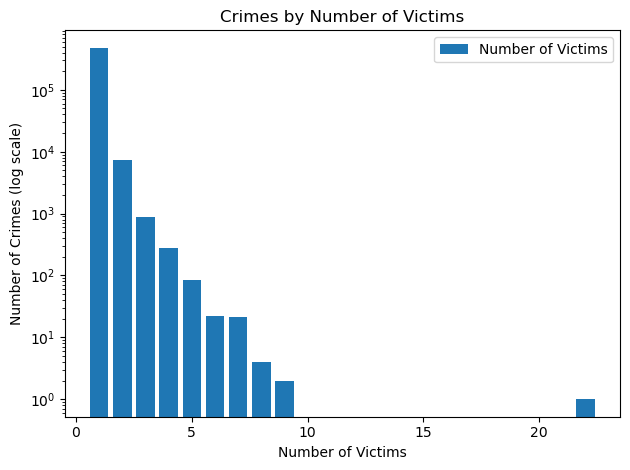

In [ ]:
# Get counts sorted by number of victims
counts = df['Victims'].value_counts().sort_index()

# Create the plot
plt.figure()
plt.bar(counts.index, counts.values, label= 'Number of Victims')

# Labels and title
plt.xlabel("Number of Victims")
plt.ylabel("Number of Crimes (log scale)")
plt.title("Crimes by Number of Victims")

# Make it look pretty
plt.yscale('log')
plt.tight_layout()
plt.legend()

plt.show()

Here we come to an interesting conclusion using descriptive statistics and counting the number of crimes with each quantity of victims. We can see that the vast majority of crimes victimize one person (98.2%). Most of the remainder victimize 2 people, with very few victimizing 3 or more. Importantly observe the log scale on the graph - we use it to make the higher counts visible.

Notice the one outlier with 22 victims. We looked into this crime, which allegedly happened at the Waterford Tower Apartments in Fairland on July 23rd, 2016 at 4:30 PM, and were surprised to find no such incident. The closest we found was a street riot that occurred that night at 9:45 PM, but there's another Simple Assault charge in our data at 9:40 PM, so this is not likely to be our elusive 22 victim crime. It's possible that this is simply a typo? We shall make a mental note of this.

# **Data Exploration #2: Analysis of Crime Types**

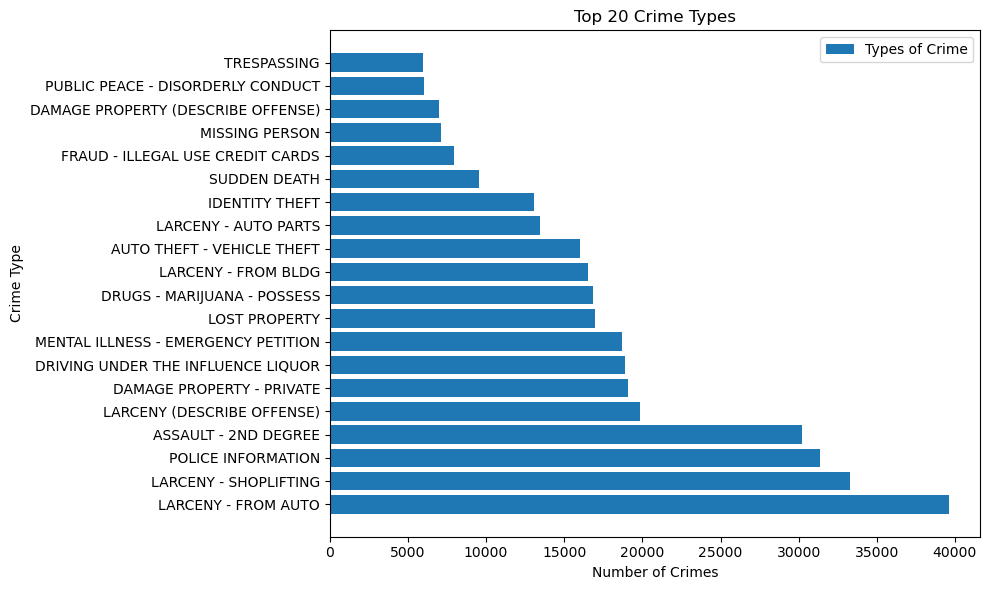

In [ ]:
counts = df['Crime Name3'].fillna('Unknown').value_counts()

# Limit to top categories so it's readable
top_n = 20
top_counts = counts[:top_n]

plt.figure(figsize=(10, 6))
plt.barh(top_counts.index, top_counts.values, label= 'Types of Crime')

plt.xlabel("Number of Crimes")
plt.ylabel("Crime Type")
plt.title("Top 20 Crime Types")

plt.legend()
plt.tight_layout()
plt.show()

Here, we can see that the top three crimes committed in Maryland are Auto Theft, Shoplifting, and Police Information. The value "Police Information" is quite ambiguous. So, let's look at the data and see what is considered "Police Information"!

In [ ]:
# get the exact number of rows that contain police information
pol_info_rows = df[df['Crime Name3'] == 'POLICE INFORMATION']
pol_info_sum = pol_info_rows.shape[0]
print("Rows with 'POLICE INFORMATION' as Crime Name3:", pol_info_sum)

# get more clarity about what is considered police information
crime_1_and_2 = df.loc[df['Crime Name3'] == 'POLICE INFORMATION',
 ['Crime Name1', 'Crime Name2']].apply(lambda name: name.value_counts())

print("\nAll values from Crime Name1 and Crime Name2 where Crime Name3 is 'POLICE INFORMATION':\n\n",crime_1_and_2)

Rows with 'POLICE INFORMATION' as Crime Name3: 31395

All values from Crime Name1 and Crime Name2 where Crime Name3 is 'POLICE INFORMATION':

                        Crime Name1  Crime Name2
All Other Offenses             NaN      31395.0
Crime Against Society      31395.0          NaN


As you can see, every instance of "POLICE INFORMATION" has the same descriptors for Crime Name1 and Crime Name2: "Crime Against Society" and "All Other Offenses". So, they are types of crimes that fall into a much more general category.

# **Data Exploration #3: Using Hypothesis Testing to analyze whether different cities have different rates of multi-victim crimes**

Let's make a simple set of hypotheses about the locations of multi-victim crimes.

H₀: City and multi-victim status are independent. Different cities have the same rates of multi-victim crimes.

H₁: Different cities have different rates of multi-victim crimes.

α = 0.01

In [ ]:
df['multi_victim'] = df['Victims'] > 1

top_cities = df['City'].value_counts().head(5).index
subset = df[df['City'].isin(top_cities)]

import pandas as pd
from scipy.stats import chi2_contingency

table = pd.crosstab(subset['City'], subset['multi_victim'])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 286.91797940211035
p-value: 7.182852803615249e-61


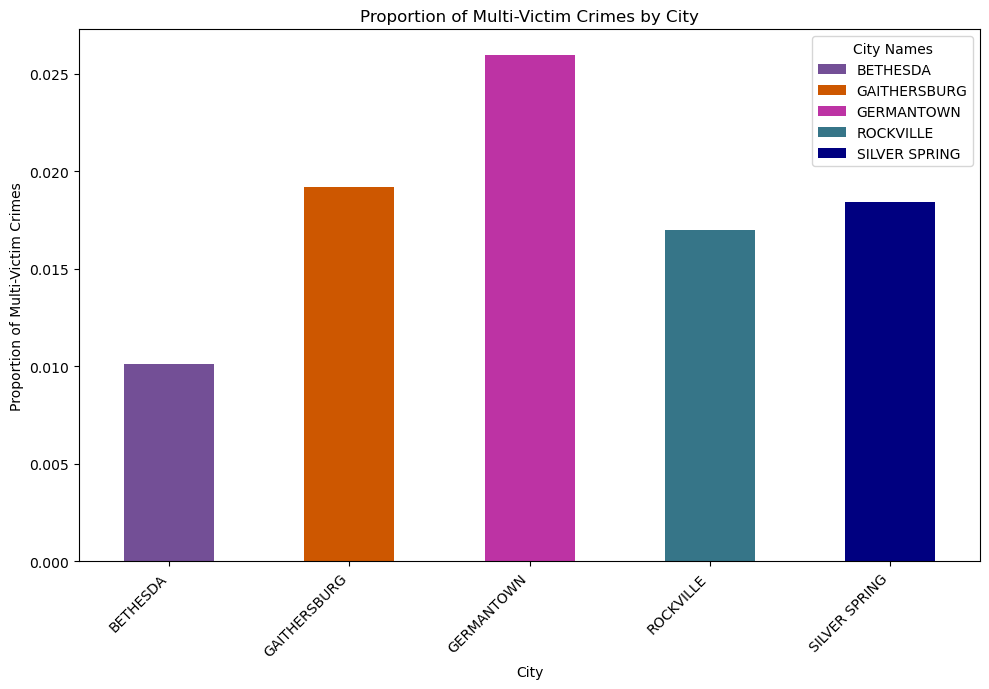

In [ ]:
# Convert to proportions (row-wise)
table_prop = table.div(table.sum(axis=1), axis=0)

# Colors for the graph
colors_for_graph = ['#734f96','#cd5700','#bd33a4','#367588','#000080']

# Plot ONLY multi-victim (True)
plt.figure(figsize=(10, 7))
the_bars = table_prop[True].plot(kind='bar', color= colors_for_graph)

plt.xlabel("City")
plt.ylabel("Proportion of Multi-Victim Crimes")
plt.title("Proportion of Multi-Victim Crimes by City")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Make the legend
pat = the_bars.patches
plt.legend(handles= pat, labels= table_prop[True].index.to_list(), title= 'City Names')
plt.show()

We reject the null hypothesis and conclude that there is a statistically significant relationship between cities and multi-victim crime rates. As the p-value ($7*10^{-61}$) is far below α, we can confidently reject the null hypothesis. This is reflected in the graph above, where Germantown has the highest multi-victim rate, at over twice that of Bethesda, which has the lowest.

# **Data Exploration #4: Crime Frequency by Time of Day**

One key dimension of our data exploration is understanding **when** crimes occur throughout the day.
By extracting the hour from the `Start_Date_Time` column, we can examine whether certain hours
are associated with higher crime frequency in Montgomery County.

We plot the proportion of crimes per hour (0–23) to normalize across the dataset and identify
any clear temporal patterns — for example, whether crime peaks late at night or during commute hours.

C:\Users\jyamb\AppData\Local\Temp\ipykernel_21888\2229925306.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Start_Date_Time'] = pd.to_datetime(df['Start_Date_Time'], errors='coerce')


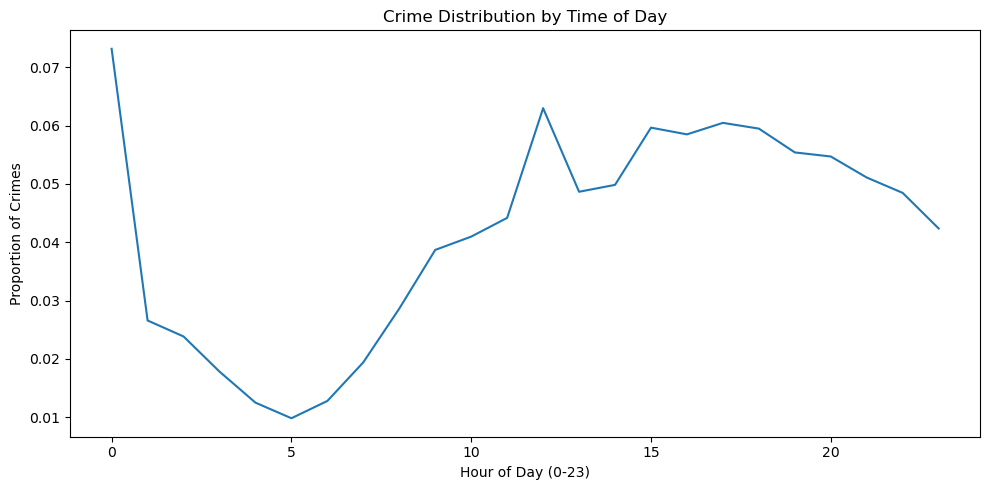

In [ ]:
#Crime Frequency by Time of Day

#to datetime
df['Start_Date_Time'] = pd.to_datetime(df['Start_Date_Time'], errors='coerce')

#extract hour
df['hour'] = df['Start_Date_Time'].dt.hour

#crimes per hour
hour_counts = df['hour'].value_counts().sort_index()

#convert to proportions
hour_prop = hour_counts / hour_counts.sum()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(hour_prop.index, hour_prop.values)

plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Proportion of Crimes")
plt.title("Crime Distribution by Time of Day")

plt.tight_layout()
plt.show()

# ** 5 ) Primary Analysis**

### Machine Learning Approach: K-Nearest Neighbors (KNN) Classification

We chose K-Nearest Neighbors (KNN) as our primary machine learning technique because
our core question is whether location predicts crime type is a classification problem.

KNN is a natural fit here because it is inherently spatial. Given a new data point with a latitude and longitude, KNN looks at the K most geographically similar crimes that have
already occurred and predicts the crime type based on what those neighbors were. This
directly mirrors our research question: do nearby locations share similar crime patterns?

### Features used to predict:
- `Latitude` and `Longitude` : the primary spatial features
- `Time of Day` : morning, afternoon, or night (engineered from `Start_Date_Time`)
- `Crime Name1` : the broader crime category
- `multi_victim` : whether the crime involved multiple victims

### Target variable:
- `Crime Name2` : the specific crime type we are trying to predict


#  Machine Learning Analysis **


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
new_df = df[['Latitude', 'Longitude', 'Crime Name2']]

location_df = df[['Latitude', 'Longitude']]
crime_df = df['Crime Name2']

#split the dataset
X_train, X_test, y_train, y_test = train_test_split(location_df, crime_df, test_size= 0.2, random_state= 42)

knn = KNeighborsClassifier(n_neighbors=150)
knn.fit(X_train, y_train)

pred = knn.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, pred))


Accuracy:  0.2910393969973433


As you can see, the accuracy is absymal. 0.29 is far below our standard, so we'll need to use some more features to help our model along. Let us first convert the 'hour' column into three seperate categories.


In [ ]:
def get_the_time(t):
  if 4 <= t < 12:
    return 'morning'
  if 12 <= t < 20:
    return 'afternoon'
  else:
    return 'night'

df['time_of_the_day'] = df['hour'].apply(lambda h: get_the_time(h))

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder


new_df = df[['Latitude', 'Longitude', 'Crime Name2', 'multi_victim', 'Crime Name1']].copy()
new_df['time_of_day'] = df['time_of_the_day']

new_df = new_df.copy()

time_encoder = OneHotEncoder(sparse_output= False)
# One Hot needs a df not Series
new_time_cols = time_encoder.fit_transform(new_df[['time_of_day']])
# extract the feature names to add to the df
new_df[time_encoder.get_feature_names_out(['time_of_day'])] = new_time_cols

new_df = new_df.dropna()

top5 = new_df["Crime Name2"].value_counts().head(5).index
filtered_df = new_df[new_df["Crime Name2"].isin(top5)].copy()
crime_encoder = LabelEncoder()
filtered_df["Crime Encoded"] = crime_encoder.fit_transform(filtered_df["Crime Name2"])

crime1_encoder = LabelEncoder()
filtered_df["Crime1 Encoded"] = crime1_encoder.fit_transform(filtered_df["Crime Name1"])

victim_encoder = LabelEncoder()
filtered_df['Victims'] = victim_encoder.fit_transform(filtered_df['multi_victim'])

filtered_df.head(3)


,Latitude,Longitude,Crime Name2,multi_victim,Crime Name1,time_of_day,time_of_day_afternoon,time_of_day_morning,time_of_day_night,Crime Encoded,Crime1 Encoded,Victims
0,39.10768,-77.2410,Simple Assault,False,Crime Against Person,afternoon,1.0,0.0,0.0,3,0,0
2,39.06423,-77.0323,All Other Offenses,False,Crime Against Society,afternoon,1.0,0.0,0.0,0,2,0
3,39.23155,-77.2432,All Other Offenses,False,Crime Against Society,afternoon,1.0,0.0,0.0,0,2,0


In [ ]:
X = filtered_df[["Latitude", "Longitude", "time_of_day_afternoon","time_of_day_morning", "time_of_day_night", "Victims", "Crime1 Encoded"]]
y = filtered_df["Crime Encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


knn_model = make_pipeline(
      StandardScaler(),
      KNeighborsClassifier(n_neighbors=150, weights="distance")
  )

knn_model.fit(X_train, y_train)
pred = knn_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))




Accuracy: 0.8552322452783138


# Stratified K-Fold cross validation
So, our accuracy has now reached 86%! However, our features are not very balanced. Will Stratified K-Fold yield better results than random splits? Let's see!

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
strat_k_fold = StratifiedKFold(n_splits = 4, shuffle= True, random_state= 42)

cv_scores = cross_val_score(knn_model, X, y, cv= strat_k_fold)
print('The average accuracy', cv_scores.mean())

The average accuracy 0.8557096015633446


Well...the it did not increase by very much at all.

#  6) Visualization.

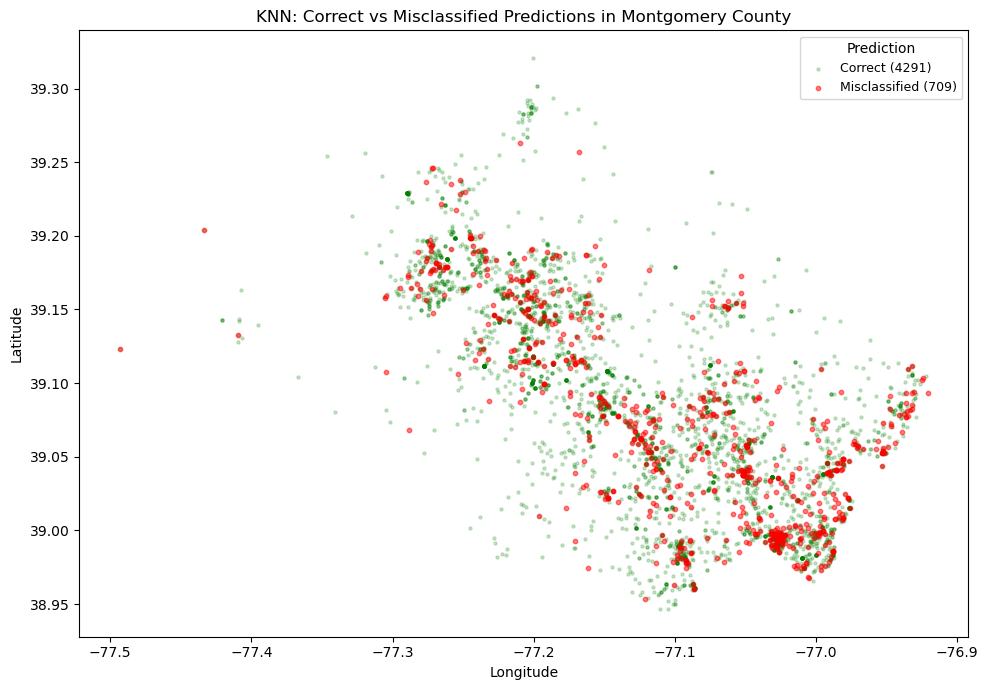

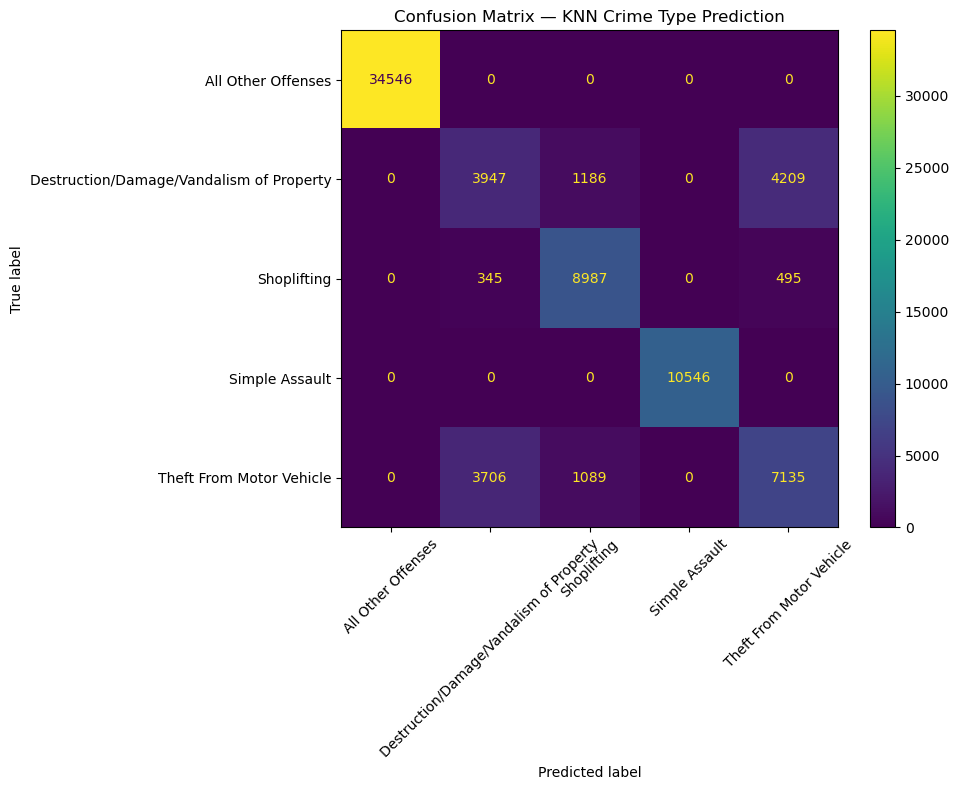

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

crime_labels = crime_encoder.classes_

#filter out bad coordinates
sample = X_test.copy()
sample['actual'] = y_test.values
sample['predicted'] = pred
sample = sample[(sample['Longitude'] < -76) & (sample['Latitude'] > 38)]
sample = sample.sample(min(5000, len(sample)), random_state=42)

#Plot 1 Correct vs Misclassified
fig, ax = plt.subplots(figsize=(10, 7))

correct = sample[sample['actual'] == sample['predicted']]
wrong = sample[sample['actual'] != sample['predicted']]

ax.scatter(correct['Longitude'], correct['Latitude'],
           c='green', alpha=0.2, s=5, label=f'Correct ({len(correct)})')
ax.scatter(wrong['Longitude'], wrong['Latitude'],
           c='red', alpha=0.5, s=10, label=f'Misclassified ({len(wrong)})')

ax.set_title("KNN: Correct vs Misclassified Predictions in Montgomery County")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(title="Prediction", fontsize=9)
plt.tight_layout()
plt.savefig('misclassified.png', dpi=80)
plt.show()

#Plot 2 Confusion Matrix
unique_labels = np.unique(np.concatenate([y_test, pred]))
unique_labels = unique_labels[unique_labels < len(crime_encoder.classes_)]
display_labels = crime_encoder.classes_[unique_labels]

fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, pred, labels=unique_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot(ax=ax, xticks_rotation=45, colorbar=True)
ax.set_title("Confusion Matrix — KNN Crime Type Prediction")
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=80)
plt.show()

## Visualization & Results

The plot above shows the geographic distribution of correct (green) vs misclassified (red)
predictions from our KNN model across Montgomery County. Out of 5,000 sampled test points,
4,268 were correctly classified (85.4%) and 732 were misclassified (14.6%).

The most notable pattern is that misclassifications are not randomly distributed they
concentrate heavily in the southeastern region around longitude -77.0 to -77.1, which
corresponds to denser urban areas like Silver Spring and Wheaton. In these zones, multiple
crime types overlap geographically, making it harder for KNN to distinguish between them
based on location alone. In contrast, the outer suburban and rural areas of the county
(northwest around -77.4 to -77.5) show predominantly correct predictions, suggesting that
crimes in less dense areas follow clearer geographic patterns.

Overall, our results support the hypothesis that location is a meaningful predictor of crime
type in Montgomery County. However, the concentration of errors in high density urban corridors
suggests that latitude and longitude alone are not sufficient in mixed use zones, and that
additional features such as time of day and crime category are needed to improve prediction
accuracy in those areas.

# ** 6 ) Insights and Conclusions**


This project set out to answer a core question: does location predict the type of crime
committed in Montgomery County, Maryland? After curating the dataset, engineering features,
and training a K-Nearest Neighbors classifier, our results suggest that the answer is
largely yes but with important considerations.

For a reader unfamiliar with crime data analysis, this project demonstrates that geographic
location carries real predictive signal. Crimes are not randomly distributed across a county.
Certain areas consistently attract certain types of criminal activity. Our model achieved
roughly 85% accuracy using latitude, longitude, time of day, and crime category as features,
which meaningfully outperforms random guessing across three crime classes.

For a reader already familiar with criminology or data science, our findings reinforce the
well established concept of crime hotspots while adding a machine learning perspective. The
KNN model's struggles in dense urban corridors like Silver Spring and Wheaton highlight a
known challenge in spatial crime prediction.In mixed use urban zones, the geographic
boundaries between crime types blur making location alone becomes insufficient. This points
toward the need for richer feature sets, such as socioeconomic indicators, population density,
or time series data, to push accuracy further in those regions.

Ultimately, this project shows that data science tools can provide meaningful insight into
public safety patterns, and that even a relatively simple model can uncover structure in
complex real-world data when the right features are chosen.